<a href="https://colab.research.google.com/github/Maria-lin/F1-Analytics/blob/main/detection_anomalies_gab_(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-- ==============================================================================
-- IDENTIFICATION DES COORDONNÉES GPS FAUSSES — RÉSEAU GAB
-- INPUT  : table_ref_gab (num_automate, code_postale_emplacement, longitude, latitude)
-- OUTPUT : gab_coordonnees_invalides
-- ==============================================================================
-- COUVERTURE GÉOGRAPHIQUE FRANCE COMPLÈTE :
--
--   MÉTROPOLE
--     France métropolitaine         lon [-5.5,  9.8]   lat [41.0, 51.5]
--
--   DOM (Départements d'Outre-Mer)
--     Guadeloupe                    lon [-61.9, -60.9]  lat [15.8, 16.6]
--     Martinique                    lon [-61.3, -60.8]  lat [14.3, 15.0]
--     Guyane                        lon [-54.7, -51.6]  lat [ 2.1,  5.8]
--     La Réunion                    lon [ 55.1,  55.9]  lat [-21.5,-20.8]
--     Mayotte                       lon [ 44.9,  45.4]  lat [-13.1,-12.5]
--
--   COM (Collectivités d'Outre-Mer)
--     Saint-Martin                  lon [-63.2, -62.9]  lat [18.0, 18.2]
--     Saint-Barthélemy              lon [-63.0, -62.7]  lat [17.8, 18.1]
--     Saint-Pierre-et-Miquelon      lon [-56.5, -56.1]  lat [46.7, 47.2]
--     Polynésie française           lon [-154.8,-134.9] lat [-28.0, -7.9]
--     Nouvelle-Calédonie            lon [163.5, 168.2]  lat [-22.8,-19.5]
--     Wallis-et-Futuna              lon [-178.3,-176.1] lat [-14.4,-13.1]
--     Saint-Martin (NL)             lon [-63.2, -62.9]  lat [18.0, 18.2]
--
-- LOGIQUE :
--   Une coordonnée est VALIDE si elle tombe dans AU MOINS UNE des zones ci-dessus.
--   Une coordonnée est INVALIDE si elle ne tombe dans AUCUNE zone.
--   On distingue aussi les cas NULL séparément.
-- ==============================================================================

SELECT

    num_automate,
    code_postale_emplacement,
    longitude,
    latitude,

    -- ── Diagnostic du type d'erreur ───────────────────────────────────────────
    CASE
        WHEN longitude IS NULL AND latitude IS NULL
            THEN 'NULL_TOTAL'
        WHEN longitude IS NULL
            THEN 'LONGITUDE_NULL'
        WHEN latitude IS NULL
            THEN 'LATITUDE_NULL'
        WHEN longitude NOT BETWEEN -180.0 AND 180.0
          OR latitude  NOT BETWEEN  -90.0 AND  90.0
            THEN 'HORS_GLOBE'
        ELSE 'HORS_TERRITOIRE_FRANCAIS'
    END AS type_erreur,

    -- ── Territoire le plus proche (aide au diagnostic) ────────────────────────
    CASE
        -- Métropole
        WHEN longitude BETWEEN  -5.5 AND   9.8  AND latitude BETWEEN  41.0 AND 51.5
            THEN 'France metropolitaine'
        -- DOM
        WHEN longitude BETWEEN -61.9 AND -60.9  AND latitude BETWEEN  15.8 AND 16.6
            THEN 'Guadeloupe'
        WHEN longitude BETWEEN -61.3 AND -60.8  AND latitude BETWEEN  14.3 AND 15.0
            THEN 'Martinique'
        WHEN longitude BETWEEN -54.7 AND -51.6  AND latitude BETWEEN   2.1 AND  5.8
            THEN 'Guyane'
        WHEN longitude BETWEEN  55.1 AND  55.9  AND latitude BETWEEN -21.5 AND -20.8
            THEN 'La Reunion'
        WHEN longitude BETWEEN  44.9 AND  45.4  AND latitude BETWEEN -13.1 AND -12.5
            THEN 'Mayotte'
        -- COM
        WHEN longitude BETWEEN -63.2 AND -62.9  AND latitude BETWEEN  18.0 AND 18.2
            THEN 'Saint-Martin'
        WHEN longitude BETWEEN -63.0 AND -62.7  AND latitude BETWEEN  17.8 AND 18.1
            THEN 'Saint-Barthelemy'
        WHEN longitude BETWEEN -56.5 AND -56.1  AND latitude BETWEEN  46.7 AND 47.2
            THEN 'Saint-Pierre-et-Miquelon'
        WHEN longitude BETWEEN -154.8 AND -134.9 AND latitude BETWEEN -28.0 AND  -7.9
            THEN 'Polynesie francaise'
        WHEN longitude BETWEEN  163.5 AND  168.2 AND latitude BETWEEN -22.8 AND -19.5
            THEN 'Nouvelle-Caledonie'
        WHEN longitude BETWEEN -178.3 AND -176.1 AND latitude BETWEEN -14.4 AND -13.1
            THEN 'Wallis-et-Futuna'
        WHEN longitude IS NULL OR latitude IS NULL
            THEN 'COORDONNEES_MANQUANTES'
        ELSE 'INVALIDE'
    END AS territoire_detecte,

    -- ── Valeurs brutes pour audit ─────────────────────────────────────────────
    ROUND(longitude, 6) AS longitude_brute,
    ROUND(latitude,  6) AS latitude_brute,

    -- ── Flag binaire pour jointure ultérieure ─────────────────────────────────
    1 AS coord_invalide

FROM table_ref_gab

-- ══════════════════════════════════════════════════════════════════════════════
-- FILTRE : on ne garde QUE les lignes avec coordonnées INVALIDES
-- Une coordonnée est valide si elle tombe dans AU MOINS UN territoire français
-- ══════════════════════════════════════════════════════════════════════════════
WHERE

    -- Cas 1 : valeurs NULL
    longitude IS NULL
    OR latitude  IS NULL

    -- Cas 2 : hors globe (impossible physiquement)
    OR longitude NOT BETWEEN -180.0 AND  180.0
    OR latitude  NOT BETWEEN  -90.0 AND   90.0

    -- Cas 3 : dans le globe mais hors de tout territoire français
    OR NOT (
        -- France métropolitaine
        (longitude BETWEEN  -5.5  AND   9.8  AND latitude BETWEEN  41.0  AND 51.5 )
        -- Guadeloupe
     OR (longitude BETWEEN -61.9  AND -60.9  AND latitude BETWEEN  15.8  AND 16.6 )
        -- Martinique
     OR (longitude BETWEEN -61.3  AND -60.8  AND latitude BETWEEN  14.3  AND 15.0 )
        -- Guyane
     OR (longitude BETWEEN -54.7  AND -51.6  AND latitude BETWEEN   2.1  AND  5.8 )
        -- La Réunion
     OR (longitude BETWEEN  55.1  AND  55.9  AND latitude BETWEEN -21.5  AND -20.8)
        -- Mayotte
     OR (longitude BETWEEN  44.9  AND  45.4  AND latitude BETWEEN -13.1  AND -12.5)
        -- Saint-Martin
     OR (longitude BETWEEN -63.2  AND -62.9  AND latitude BETWEEN  18.0  AND 18.2 )
        -- Saint-Barthélemy
     OR (longitude BETWEEN -63.0  AND -62.7  AND latitude BETWEEN  17.8  AND 18.1 )
        -- Saint-Pierre-et-Miquelon
     OR (longitude BETWEEN -56.5  AND -56.1  AND latitude BETWEEN  46.7  AND 47.2 )
        -- Polynésie française (grande zone, archipels épars)
     OR (longitude BETWEEN -154.8 AND -134.9 AND latitude BETWEEN -28.0  AND  -7.9)
        -- Nouvelle-Calédonie
     OR (longitude BETWEEN  163.5 AND  168.2 AND latitude BETWEEN -22.8  AND -19.5)
        -- Wallis-et-Futuna
     OR (longitude BETWEEN -178.3 AND -176.1 AND latitude BETWEEN -14.4  AND -13.1)
    )
;

-- ==============================================================================
-- REQUÊTE DE VÉRIFICATION — À lancer sur la table output pour avoir le bilan
-- ==============================================================================
--
-- SELECT
--     type_erreur,
--     territoire_detecte,
--     COUNT(*)   AS nb_gab,
--     ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_total
-- FROM gab_coordonnees_invalides
-- GROUP BY type_erreur, territoire_detecte
-- ORDER BY nb_gab DESC
-- ;
--
-- RÉSULTATS ATTENDUS :
--   type_erreur = NULL_TOTAL              → coordonnées complètement absentes
--   type_erreur = LONGITUDE_NULL          → longitude seule manquante
--   type_erreur = LATITUDE_NULL           → latitude seule manquante
--   type_erreur = HORS_GLOBE              → valeur impossible (ex: lon=999, lat=200)
--   type_erreur = HORS_TERRITOIRE_FRANCAIS → lon/lat valides mais pas en France
--
-- ==============================================================================
-- ÉTAPE SUIVANTE : recette de correction
-- Joindre gab_coordonnees_invalides avec base_ban sur code_postale_emplacement
-- pour remplacer les coordonnées fausses par le centroïde BAN du code postal
-- ==============================================================================


In [18]:
-- ==============================================================================
-- IDENTIFICATION DES COORDONNÉES GPS FAUSSES — RÉSEAU GAB
-- INPUT  : table_ref_gab (num_automate, code_postale_emplacement, longitude, latitude)
-- OUTPUT : gab_coordonnees_invalides
-- ==============================================================================
-- COUVERTURE GÉOGRAPHIQUE FRANCE COMPLÈTE :
--
--   MÉTROPOLE
--     France métropolitaine         lon [-5.5,  9.8]   lat [41.0, 51.5]
--
--   DOM (Départements d'Outre-Mer)
--     Guadeloupe                    lon [-61.9, -60.9]  lat [15.8, 16.6]
--     Martinique                    lon [-61.3, -60.8]  lat [14.3, 15.0]
--     Guyane                        lon [-54.7, -51.6]  lat [ 2.1,  5.8]
--     La Réunion                    lon [ 55.1,  55.9]  lat [-21.5,-20.8]
--     Mayotte                       lon [ 44.9,  45.4]  lat [-13.1,-12.5]
--
--   COM (Collectivités d'Outre-Mer)
--     Saint-Martin                  lon [-63.2, -62.9]  lat [18.0, 18.2]
--     Saint-Barthélemy              lon [-63.0, -62.7]  lat [17.8, 18.1]
--     Saint-Pierre-et-Miquelon      lon [-56.5, -56.1]  lat [46.7, 47.2]
--     Polynésie française           lon [-154.8,-134.9] lat [-28.0, -7.9]
--     Nouvelle-Calédonie            lon [163.5, 168.2]  lat [-22.8,-19.5]
--     Wallis-et-Futuna              lon [-178.3,-176.1] lat [-14.4,-13.1]
--     Saint-Martin (NL)             lon [-63.2, -62.9]  lat [18.0, 18.2]
--
-- LOGIQUE :
--   Une coordonnée est VALIDE si elle tombe dans AU MOINS UNE des zones ci-dessus.
--   Une coordonnée est INVALIDE si elle ne tombe dans AUCUNE zone.
--   On distingue aussi les cas NULL séparément.
-- ==============================================================================

SELECT

    num_automate,
    code_postale_emplacement,
    longitude,
    latitude,

    -- ── Diagnostic du type d'erreur ───────────────────────────────────────────
    CASE
        WHEN longitude IS NULL AND latitude IS NULL
            THEN 'NULL_TOTAL'
        WHEN longitude IS NULL
            THEN 'LONGITUDE_NULL'
        WHEN latitude IS NULL
            THEN 'LATITUDE_NULL'
        WHEN longitude NOT BETWEEN -180.0 AND 180.0
          OR latitude  NOT BETWEEN  -90.0 AND  90.0
            THEN 'HORS_GLOBE'
        ELSE 'HORS_TERRITOIRE_FRANCAIS'
    END AS type_erreur,

    -- ── Territoire le plus proche (aide au diagnostic) ────────────────────────
    CASE
        -- Métropole
        WHEN longitude BETWEEN  -5.5 AND   9.8  AND latitude BETWEEN  41.0 AND 51.5
            THEN 'France metropolitaine'
        -- DOM
        WHEN longitude BETWEEN -61.9 AND -60.9  AND latitude BETWEEN  15.8 AND 16.6
            THEN 'Guadeloupe'
        WHEN longitude BETWEEN -61.3 AND -60.8  AND latitude BETWEEN  14.3 AND 15.0
            THEN 'Martinique'
        WHEN longitude BETWEEN -54.7 AND -51.6  AND latitude BETWEEN   2.1 AND  5.8
            THEN 'Guyane'
        WHEN longitude BETWEEN  55.1 AND  55.9  AND latitude BETWEEN -21.5 AND -20.8
            THEN 'La Reunion'
        WHEN longitude BETWEEN  44.9 AND  45.4  AND latitude BETWEEN -13.1 AND -12.5
            THEN 'Mayotte'
        -- COM
        WHEN longitude BETWEEN -63.2 AND -62.9  AND latitude BETWEEN  18.0 AND 18.2
            THEN 'Saint-Martin'
        WHEN longitude BETWEEN -63.0 AND -62.7  AND latitude BETWEEN  17.8 AND 18.1
            THEN 'Saint-Barthelemy'
        WHEN longitude BETWEEN -56.5 AND -56.1  AND latitude BETWEEN  46.7 AND 47.2
            THEN 'Saint-Pierre-et-Miquelon'
        WHEN longitude BETWEEN -154.8 AND -134.9 AND latitude BETWEEN -28.0 AND  -7.9
            THEN 'Polynesie francaise'
        WHEN longitude BETWEEN  163.5 AND  168.2 AND latitude BETWEEN -22.8 AND -19.5
            THEN 'Nouvelle-Caledonie'
        WHEN longitude BETWEEN -178.3 AND -176.1 AND latitude BETWEEN -14.4 AND -13.1
            THEN 'Wallis-et-Futuna'
        WHEN longitude IS NULL OR latitude IS NULL
            THEN 'COORDONNEES_MANQUANTES'
        ELSE 'INVALIDE'
    END AS territoire_detecte,

    -- ── Valeurs brutes pour audit ─────────────────────────────────────────────
    ROUND(longitude, 6) AS longitude_brute,
    ROUND(latitude,  6) AS latitude_brute,

    -- ── Flag binaire pour jointure ultérieure ─────────────────────────────────
    1 AS coord_invalide

FROM table_ref_gab

-- ══════════════════════════════════════════════════════════════════════════════
-- FILTRE : on ne garde QUE les lignes avec coordonnées INVALIDES
-- Une coordonnée est valide si elle tombe dans AU MOINS UN territoire français
-- ══════════════════════════════════════════════════════════════════════════════
WHERE

    -- Cas 1 : valeurs NULL
    longitude IS NULL
    OR latitude  IS NULL

    -- Cas 2 : hors globe (impossible physiquement)
    OR longitude NOT BETWEEN -180.0 AND  180.0
    OR latitude  NOT BETWEEN  -90.0 AND   90.0

    -- Cas 3 : dans le globe mais hors de tout territoire français
    OR NOT (
        -- France métropolitaine
        (longitude BETWEEN  -5.5  AND   9.8  AND latitude BETWEEN  41.0  AND 51.5 )
        -- Guadeloupe
     OR (longitude BETWEEN -61.9  AND -60.9  AND latitude BETWEEN  15.8  AND 16.6 )
        -- Martinique
     OR (longitude BETWEEN -61.3  AND -60.8  AND latitude BETWEEN  14.3  AND 15.0 )
        -- Guyane
     OR (longitude BETWEEN -54.7  AND -51.6  AND latitude BETWEEN   2.1  AND  5.8 )
        -- La Réunion
     OR (longitude BETWEEN  55.1  AND  55.9  AND latitude BETWEEN -21.5  AND -20.8)
        -- Mayotte
     OR (longitude BETWEEN  44.9  AND  45.4  AND latitude BETWEEN -13.1  AND -12.5)
        -- Saint-Martin
     OR (longitude BETWEEN -63.2  AND -62.9  AND latitude BETWEEN  18.0  AND 18.2 )
        -- Saint-Barthélemy
     OR (longitude BETWEEN -63.0  AND -62.7  AND latitude BETWEEN  17.8  AND 18.1 )
        -- Saint-Pierre-et-Miquelon
     OR (longitude BETWEEN -56.5  AND -56.1  AND latitude BETWEEN  46.7  AND 47.2 )
        -- Polynésie française (grande zone, archipels épars)
     OR (longitude BETWEEN -154.8 AND -134.9 AND latitude BETWEEN -28.0  AND  -7.9)
        -- Nouvelle-Calédonie
     OR (longitude BETWEEN  163.5 AND  168.2 AND latitude BETWEEN -22.8  AND -19.5)
        -- Wallis-et-Futuna
     OR (longitude BETWEEN -178.3 AND -176.1 AND latitude BETWEEN -14.4  AND -13.1)
    )
;

-- ==============================================================================
-- REQUÊTE DE VÉRIFICATION — À lancer sur la table output pour avoir le bilan
-- ==============================================================================
--
-- SELECT
--     type_erreur,
--     territoire_detecte,
--     COUNT(*)   AS nb_gab,
--     ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_total
-- FROM gab_coordonnees_invalides
-- GROUP BY type_erreur, territoire_detecte
-- ORDER BY nb_gab DESC
-- ;
--
-- RÉSULTATS ATTENDUS :
--   type_erreur = NULL_TOTAL              → coordonnées complètement absentes
--   type_erreur = LONGITUDE_NULL          → longitude seule manquante
--   type_erreur = LATITUDE_NULL           → latitude seule manquante
--   type_erreur = HORS_GLOBE              → valeur impossible (ex: lon=999, lat=200)
--   type_erreur = HORS_TERRITOIRE_FRANCAIS → lon/lat valides mais pas en France
--
-- ==============================================================================
-- ÉTAPE SUIVANTE : recette de correction
-- Joindre gab_coordonnees_invalides avec base_ban sur code_postale_emplacement
-- pour remplacer les coordonnées fausses par le centroïde BAN du code postal
-- ==============================================================================


SyntaxError: invalid character '—' (U+2014) (367082156.py, line 2)

## 1. 🧠 Comment fonctionne le modèle ? (Expliqué simplement)

### L'analogie de la forêt

Imaginez que vous voulez **trouver Waldo** dans une foule.

Le modèle fait exactement ça, mais avec des données :

---

**Étape 1 — Il observe tous les GAB**  
Il regarde chaque automate sur toutes ses dimensions : volume de retraits, montants, taux de capture, activité nocturne, réseau de carte...

**Étape 2 — Il construit des « questions » aléatoires**  
Par exemple :  
> *« Le taux de capture est-il supérieur à 2.3% ? »*  
> *« Le montant moyen est-il inférieur à 87€ ? »*  

**Étape 3 — Il compte combien de questions il faut pour isoler un GAB**

- 🟢 **Un GAB NORMAL** ressemble à beaucoup d'autres → il faut **beaucoup de questions** pour l'isoler  
- 🔴 **Un GAB ATYPIQUE** est différent des autres → il suffit de **peu de questions** pour l'isoler

---

### En image mentale :

```
GAB NORMAL    → Au milieu de la foule → Difficile à isoler → SCORE BAS  
GAB ATYPIQUE  → Tout seul dans un coin → Facile à isoler  → SCORE ÉLEVÉ
```

---

### Ce que le modèle NE fait PAS :
- ❌ Il ne dit pas « ce GAB est frauduleux »  
- ❌ Il ne connaît pas la cause du comportement  
- ✅ Il dit « ce GAB se comporte différemment des autres, il mérite d'être regardé »

---

### Le score de risque :
| Score | Interprétation |
|---|---|
| 0.0 – 0.4 | 🟢 Comportement normal |
| 0.4 – 0.6 | 🟡 Légèrement inhabituel |
| 0.6 – 0.8 | 🟠 Atypique — à surveiller |
| 0.8 – 1.0 | 🔴 Très atypique — à investiguer |

---

## 2. ⚙️ Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

try:
    import shap
    SHAP_OK = True
    print('✅ SHAP disponible')
except ImportError:
    SHAP_OK = False
    print('⚠️  SHAP non installé → pip install shap')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COULEUR_NORMAL   = '#2196F3'
COULEUR_ANOMALIE = '#F44336'
COULEUR_ATTENTION= '#FF9800'

print('✅ Librairies chargées.')

✅ SHAP disponible
✅ Librairies chargées.


## 3. 📂 Chargement des Données

> **En production Dataiku**, remplacer le bloc de simulation par :
> ```python
> import dataiku
> df = dataiku.Dataset('fiche_identite_gab').get_dataframe()
> ```

In [2]:
# ── Simulation de données réalistes ────────────────────────────────────────
np.random.seed(42)
n_normal, n_anomalie = 450, 30

def generer_dataset(n_normal=450, n_anomalie=30):

    df_normal = pd.DataFrame({
        'num_automate'        : [f'GAB_{i:04d}' for i in range(n_normal)],
        'annee'               : np.random.choice([2024, 2025], n_normal),
        'mois'                : np.random.randint(1, 13, n_normal),
        'ret_nb'              : np.random.normal(800,  150, n_normal).clip(100),
        'ret_montant_total'   : np.random.normal(120000, 25000, n_normal).clip(5000),
        'ret_montant_moyen'   : np.random.normal(150, 30, n_normal).clip(50),
        'ret_montant_max'     : np.random.normal(500, 80, n_normal).clip(200),
        'ret_montant_stddev'  : np.random.normal(60, 15, n_normal).clip(5),
        'ret_nb_nuit'         : np.random.normal(80, 25, n_normal).clip(0),
        'ret_nb_weekend'      : np.random.normal(180, 40, n_normal).clip(0),
        'ret_pct_nuit'        : np.random.normal(10, 3, n_normal).clip(0, 100),
        'ret_pct_weekend'     : np.random.normal(22, 5, n_normal).clip(0, 100),
        'cap_nb'              : np.random.poisson(4, n_normal),
        'taux_capture_pct'    : np.random.normal(0.5, 0.3, n_normal).clip(0),
        'type_gab_e_i'        : np.random.choice(['Interne','Externe'], n_normal, p=[0.4,0.6]),
        'code_postal'         : np.random.choice(['75001','69001','13001','33000','31000'], n_normal),
        'longitude'           : np.random.uniform(-4.5, 8.2, n_normal),
        'latitude'            : np.random.uniform(42.3, 51.1, n_normal),
        'nb_ope_reseau_cb'  : np.random.normal(350, 60, n_normal).clip(0),
        'nb_ope_reseau_visa'  : np.random.normal(180, 40, n_normal).clip(0),
        'nb_ope_reseau_mastercard'  : np.random.normal(120, 30, n_normal).clip(0),
        'nb_ope_reseau_interne'  : np.random.normal(80, 20, n_normal).clip(0),
        'nb_ope_reseau_franfinance'  : np.random.normal(30, 10, n_normal).clip(0),
        'nb_ope_reseau_accord'  : np.random.normal(25, 10, n_normal).clip(0),
        'nb_ope_reseau_trionis'  : np.random.normal(15, 8, n_normal).clip(0),
        'nb_ope_reseau_ppl'  : np.random.normal(12, 6, n_normal).clip(0),
        'nb_ope_reseau_casino'  : np.random.normal(10, 5, n_normal).clip(0),
        'nb_ope_reseau_configona'  : np.random.normal(8, 4, n_normal).clip(0),
        'nb_ope_reseau_cos'  : np.random.normal(6, 3, n_normal).clip(0),
        'nb_ope_reseau_jcb'  : np.random.normal(4, 3, n_normal).clip(0),
        'nb_ope_reseau_postepargne'  : np.random.normal(5, 3, n_normal).clip(0),
        'nb_ope_reseau_diners_et_discovery'  : np.random.normal(3, 2, n_normal).clip(0),
        'nb_ope_reseau_autres'  : np.random.normal(10, 5, n_normal).clip(0),
    })

    df_anomalie = pd.DataFrame({
        'num_automate'        : [f'GAB_ANOM_{i:03d}' for i in range(n_anomalie)],
        'annee'               : np.random.choice([2024, 2025], n_anomalie),
        'mois'                : np.random.randint(1, 13, n_anomalie),
        'ret_nb'              : np.random.normal(1800, 200, n_anomalie).clip(0),
        'ret_montant_total'   : np.random.normal(350000, 60000, n_anomalie).clip(1000),
        'ret_montant_moyen'   : np.random.normal(420, 80, n_anomalie).clip(100),
        'ret_montant_max'     : np.random.normal(1200, 200, n_anomalie).clip(300),
        'ret_montant_stddev'  : np.random.normal(180, 40, n_anomalie).clip(5),
        'ret_nb_nuit'         : np.random.normal(250, 60, n_anomalie).clip(0),
        'ret_nb_weekend'      : np.random.normal(500, 80, n_anomalie).clip(0),
        'ret_pct_nuit'        : np.random.normal(35, 8, n_anomalie).clip(0, 100),
        'ret_pct_weekend'     : np.random.normal(45, 8, n_anomalie).clip(0, 100),
        'cap_nb'              : np.random.poisson(25, n_anomalie),
        'taux_capture_pct'    : np.random.normal(8.5, 2.5, n_anomalie).clip(0),
        'type_gab_e_i'        : np.random.choice(['Interne','Externe'], n_anomalie),
        'code_postal'         : np.random.choice(['75001','69001','13001'], n_anomalie),
        'longitude'           : np.random.uniform(-4.5, 8.2, n_anomalie),
        'latitude'            : np.random.uniform(42.3, 51.1, n_anomalie),
        'nb_ope_reseau_cb'  : np.random.normal(20, 10, n_anomalie).clip(0),
        'nb_ope_reseau_visa'  : np.random.normal(180, 40, n_anomalie).clip(0),
        'nb_ope_reseau_mastercard'  : np.random.normal(120, 30, n_anomalie).clip(0),
        'nb_ope_reseau_interne'  : np.random.normal(80, 20, n_anomalie).clip(0),
        'nb_ope_reseau_franfinance'  : np.random.normal(400, 80, n_anomalie).clip(0),
        'nb_ope_reseau_accord'  : np.random.normal(25, 10, n_anomalie).clip(0),
        'nb_ope_reseau_trionis'  : np.random.normal(15, 8, n_anomalie).clip(0),
        'nb_ope_reseau_ppl'  : np.random.normal(12, 6, n_anomalie).clip(0),
        'nb_ope_reseau_casino'  : np.random.normal(10, 5, n_anomalie).clip(0),
        'nb_ope_reseau_configona'  : np.random.normal(8, 4, n_anomalie).clip(0),
        'nb_ope_reseau_cos'  : np.random.normal(6, 3, n_anomalie).clip(0),
        'nb_ope_reseau_jcb'  : np.random.normal(4, 3, n_anomalie).clip(0),
        'nb_ope_reseau_postepargne'  : np.random.normal(5, 3, n_anomalie).clip(0),
        'nb_ope_reseau_diners_et_discovery'  : np.random.normal(3, 2, n_anomalie).clip(0),
        'nb_ope_reseau_autres'  : np.random.normal(10, 5, n_anomalie).clip(0),
    })

    return pd.concat([df_normal, df_anomalie], ignore_index=True)

df = generer_dataset()
print(f'📊 Dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head(3)

📊 Dataset : 480 lignes × 33 colonnes


,num_automate,annee,mois,ret_nb,ret_montant_total,ret_montant_moyen,ret_montant_max,ret_montant_stddev,ret_nb_nuit,ret_nb_weekend,...,nb_ope_reseau_accord,nb_ope_reseau_trionis,nb_ope_reseau_ppl,nb_ope_reseau_casino,nb_ope_reseau_configona,nb_ope_reseau_cos,nb_ope_reseau_jcb,nb_ope_reseau_postepargne,nb_ope_reseau_diners_et_discovery,nb_ope_reseau_autres
0,GAB_0000,2024,6,1027.434998,133587.477570,143.245604,506.649797,67.043577,49.116405,172.703275,...,23.517771,26.953135,11.352098,11.087367,9.984994,8.665341,4.791457,5.491614,4.333085,12.857653
1,GAB_0001,2025,6,846.868772,147090.241348,155.927368,462.631727,70.711552,109.116630,181.243039,...,30.052613,16.611156,11.322113,14.539262,13.931331,5.734182,4.723228,5.988901,4.347538,16.939230
2,GAB_0002,2024,3,753.046444,98736.088533,223.946329,441.296962,57.692610,96.768524,152.933168,...,21.329774,13.454758,17.366753,8.427781,10.819158,6.009594,3.438777,2.264653,1.144571,4.403046


## 4. 🔬 Diagnostic Qualité des Données

> ⚠️ **Cette section est critique.**  
> Un mauvais modèle vient souvent de mauvaises données, pas d'un mauvais algorithme.  
> Nous analysons ici chaque problème potentiel avant de modéliser.

### Les 4 types de problèmes possibles :
| Problème | Impact sur le modèle | Action |
|---|---|---|
| Valeurs nulles / manquantes | Le modèle peut planter ou biaiser les résultats | Imputation ou exclusion |
| Valeurs aberrantes extrêmes | Un GAB semble atypique à cause d'une erreur de saisie | Correction ou winsorisation |
| Colonnes constantes | Aucune information utile | Suppression |
| Colonnes très corrélées | Poids double sur la même info | Réduction |

In [3]:
# ── 4.1 Vue d'ensemble des valeurs manquantes ─────────────────────────────────
print('='*65)
print('  RAPPORT QUALITÉ DONNÉES')
print('='*65)

# Injecter artificiellement des NaN pour simuler le cas réel
np.random.seed(0)
for col in ['ret_montant_stddev', 'taux_capture_pct', 'ret_nb_nuit']:
    idx = np.random.choice(df.index, size=int(len(df)*0.08), replace=False)
    df.loc[idx, col] = np.nan

manquants = df.isnull().sum()
pct_manquants = (df.isnull().mean() * 100).round(2)
rapport = pd.DataFrame({
    'Valeurs manquantes' : manquants,
    '% manquant'        : pct_manquants,
    'Type'              : df.dtypes,
    'Statut'            : manquants.apply(
        lambda x: '🔴 Critique (>10%)' if x/len(df)>0.1
                  else '🟡 Notable (>5%)' if x/len(df)>0.05
                  else '🟢 OK' if x==0
                  else '🟡 Faible (<5%)')
}).sort_values('% manquant', ascending=False)

print(rapport[rapport['Valeurs manquantes']>0].to_string())
print(f'\n✅ Colonnes sans manquants : {(manquants==0).sum()}/{len(manquants)}')

  RAPPORT QUALITÉ DONNÉES
                    Valeurs manquantes  % manquant     Type           Statut
ret_montant_stddev                  38        7.92  float64  🟡 Notable (>5%)
taux_capture_pct                    38        7.92  float64  🟡 Notable (>5%)
ret_nb_nuit                         38        7.92  float64  🟡 Notable (>5%)

✅ Colonnes sans manquants : 30/33


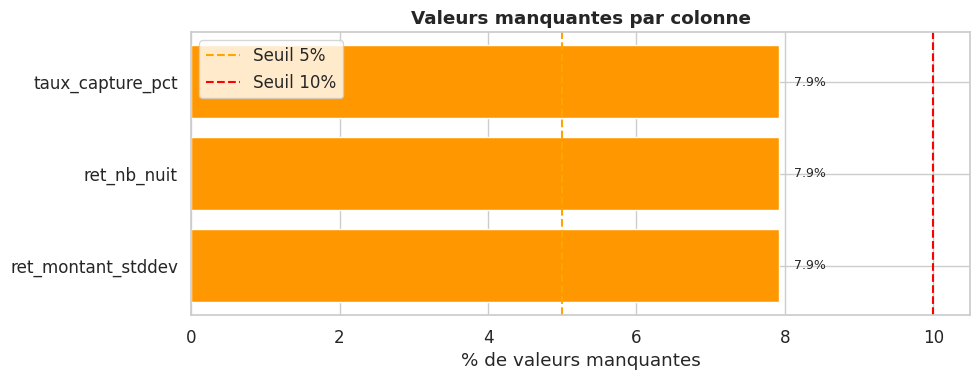

In [4]:
# ── 4.2 Visualisation des valeurs manquantes ──────────────────────────────────
cols_avec_nan = manquants[manquants > 0].index.tolist()

if cols_avec_nan:
    fig, ax = plt.subplots(figsize=(10, 4))
    pct = pct_manquants[cols_avec_nan].sort_values(ascending=True)
    couleurs = ['#F44336' if v>10 else '#FF9800' if v>5 else '#FFC107' for v in pct.values]
    bars = ax.barh(pct.index, pct.values, color=couleurs, edgecolor='white')
    ax.axvline(5,  color='orange', ls='--', lw=1.5, label='Seuil 5%')
    ax.axvline(10, color='red',    ls='--', lw=1.5, label='Seuil 10%')
    ax.set_xlabel('% de valeurs manquantes')
    ax.set_title('Valeurs manquantes par colonne', fontweight='bold')
    ax.legend()
    for bar, val in zip(bars, pct.values):
        ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('qualite_nan.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('✅ Aucune valeur manquante détectée.')

In [5]:
# ── 4.3 Détection des valeurs aberrantes par colonne (IQR) ───────────────────
print('\n🔍 Valeurs aberrantes (méthode IQR) :')
print('-'*55)

cols_num = df.select_dtypes(include=[np.number]).columns.tolist()
rapport_aberrants = []

for col in cols_num:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    n_inf = (s < Q1 - 3*IQR).sum()
    n_sup = (s > Q3 + 3*IQR).sum()
    if n_inf + n_sup > 0:
        rapport_aberrants.append({
            'Colonne'     : col,
            'Nb < Q1-3IQR': n_inf,
            'Nb > Q3+3IQR': n_sup,
            'Total'       : n_inf + n_sup,
            'Min observé' : round(s.min(), 2),
            'Max observé' : round(s.max(), 2),
        })

if rapport_aberrants:
    df_aber = pd.DataFrame(rapport_aberrants).sort_values('Total', ascending=False)
    display(df_aber)
    print('\n💡 Ces valeurs extrêmes peuvent être :')
    print('   → De vraies anomalies (intéressantes pour le modèle)')
    print('   → Des erreurs de saisie (à corriger avant modélisation)')
    print('   → Des cas exceptionnels légitimes (à garder)')
else:
    print('✅ Aucune valeur aberrante extrême détectée.')


🔍 Valeurs aberrantes (méthode IQR) :
-------------------------------------------------------


,Colonne,Nb < Q1-3IQR,Nb > Q3+3IQR,Total,Min observé,Max observé
2,ret_montant_moyen,0,30,30,63.35,543.03
9,cap_nb,0,30,30,0.00,37.00
12,nb_ope_reseau_franfinance,0,30,30,2.60,521.28
1,ret_montant_total,0,29,29,32979.78,443460.76
6,ret_nb_weekend,0,27,27,74.36,725.93
10,taux_capture_pct,0,27,27,0.00,13.75
7,ret_pct_nuit,0,27,27,1.30,47.44
3,ret_montant_max,0,26,26,273.40,1460.23
0,ret_nb,0,25,25,388.86,2153.59
5,ret_nb_nuit,0,25,25,0.00,411.88



💡 Ces valeurs extrêmes peuvent être :
   → De vraies anomalies (intéressantes pour le modèle)
   → Des erreurs de saisie (à corriger avant modélisation)
   → Des cas exceptionnels légitimes (à garder)


In [6]:
# ── 4.4 Traitement des valeurs manquantes ─────────────────────────────────────
print('🔧 Traitement des valeurs manquantes...')

# Stratégie : imputation par la médiane (robuste aux outliers)
# pour les colonnes numériques avec peu de manquants (<20%)
for col in df.select_dtypes(include=[np.number]).columns:
    pct_nan = df[col].isnull().mean()
    if 0 < pct_nan < 0.20:
        mediane = df[col].median()
        df[col] = df[col].fillna(mediane)
        print(f'   ✅ {col} : {pct_nan*100:.1f}% NaN → imputés par médiane ({mediane:.2f})')
    elif pct_nan >= 0.20:
        print(f'   ⚠️  {col} : {pct_nan*100:.1f}% NaN → trop élevé, colonne exclue du modèle')

print('\n✅ Données prêtes pour la modélisation.')

🔧 Traitement des valeurs manquantes...
   ✅ ret_montant_stddev : 7.9% NaN → imputés par médiane (62.15)
   ✅ ret_nb_nuit : 7.9% NaN → imputés par médiane (81.37)
   ✅ taux_capture_pct : 7.9% NaN → imputés par médiane (0.51)

✅ Données prêtes pour la modélisation.


## 5. ⚙️ Feature Engineering

Création de variables métier enrichies à partir des données brutes.

In [7]:
# ── Variables dérivées métier ─────────────────────────────────────────────────
df['intensite_retrait']        = df['ret_nb'] / 30
df['ratio_capture']            = df['cap_nb'] / (df['ret_nb'] + 1)
df['nb_ope_total_reseau']      = df[['nb_ope_reseau_franfinance', 'nb_ope_reseau_cb', 'nb_ope_reseau_trionis', 'nb_ope_reseau_ppl', 'nb_ope_reseau_mastercard', 'nb_ope_reseau_configona', 'nb_ope_reseau_interne', 'nb_ope_reseau_casino', 'nb_ope_reseau_accord', 'nb_ope_reseau_visa', 'nb_ope_reseau_cos', 'nb_ope_reseau_jcb', 'nb_ope_reseau_postepargne', 'nb_ope_reseau_diners_et_discovery', 'nb_ope_reseau_autres']].sum(axis=1)
df['concentration_reseau']     = df[['nb_ope_reseau_franfinance', 'nb_ope_reseau_cb', 'nb_ope_reseau_trionis', 'nb_ope_reseau_ppl', 'nb_ope_reseau_mastercard', 'nb_ope_reseau_configona', 'nb_ope_reseau_interne', 'nb_ope_reseau_casino', 'nb_ope_reseau_accord', 'nb_ope_reseau_visa', 'nb_ope_reseau_cos', 'nb_ope_reseau_jcb', 'nb_ope_reseau_postepargne', 'nb_ope_reseau_diners_et_discovery', 'nb_ope_reseau_autres']].max(axis=1) / (df['nb_ope_total_reseau'] + 1)
df['score_horaires_atypiques'] = (df['ret_pct_nuit'] / 10) + (df['ret_pct_weekend'] / 22)
df['cv_montant']               = df['ret_montant_stddev'] / (df['ret_montant_moyen'] + 1)

print('✅ Features enrichies créées.')
print(df[['intensite_retrait','ratio_capture','concentration_reseau',
          'score_horaires_atypiques','cv_montant']].describe().round(3))

✅ Features enrichies créées.
       intensite_retrait  ratio_capture  concentration_reseau  \
count            480.000        480.000               480.000   
mean              28.440          0.006                 0.406   
std                9.396          0.004                 0.053   
min               12.962          0.000                 0.238   
25%               23.342          0.003                 0.372   
50%               26.847          0.005                 0.410   
75%               30.864          0.007                 0.444   
max               71.786          0.023                 0.550   

       score_horaires_atypiques  cv_montant  
count                   480.000     480.000  
mean                      2.214       0.417  
std                       0.931       0.136  
min                       1.084       0.044  
25%                       1.763       0.324  
50%                       2.037       0.405  
75%                       2.307       0.482  
max              

## 6. 🤖 Modélisation — Isolation Forest

### Rappel visuel du fonctionnement

```
Tous les GAB du réseau
        │
        ▼
┌─────────────────────────────────────────────────────┐
│  Le modèle pose des questions aléatoires :          │
│                                                     │
│  Q1: taux_capture > 2.1% ?  ──► OUI/NON            │
│  Q2: ret_nb < 234 ?          ──► OUI/NON            │
│  Q3: ret_pct_nuit > 18% ?    ──► OUI/NON            │
│  ...                                                │
│                                                     │
│  GAB normal   → besoin de 47 questions pour isoler  │
│  GAB atypique → besoin de 6 questions pour isoler   │
└─────────────────────────────────────────────────────┘
        │
        ▼
   Score de risque [0 → 1]
   Plus court à isoler = Score plus élevé = Plus atypique
```

Le modèle répète ça **200 fois** (200 arbres) et fait la moyenne → résultat stable.

In [8]:
# ── Sélection des features ────────────────────────────────────────────────────
FEATURES_MODELE = [
    # Volume et montants
    'ret_nb',
    'ret_montant_moyen',
    'ret_montant_max',
    'ret_montant_stddev',
    'ret_montant_total',
    # Captures
    'taux_capture_pct',
    'ratio_capture',
    # Horaires
    'ret_pct_nuit',
    'ret_pct_weekend',
    'score_horaires_atypiques',
    # Intensité
    'intensite_retrait',
    'cv_montant',
    # Réseau cartes
    'concentration_reseau',
    'nb_ope_reseau_franfinance',
    'nb_ope_reseau_cb',
    'nb_ope_reseau_trionis',
    'nb_ope_reseau_ppl',
    'nb_ope_reseau_mastercard',
    'nb_ope_reseau_configona',
    'nb_ope_reseau_interne',
    'nb_ope_reseau_casino',
    'nb_ope_reseau_accord',
    'nb_ope_reseau_visa',
    'nb_ope_reseau_cos',
    'nb_ope_reseau_jcb',
    'nb_ope_reseau_postepargne',
    'nb_ope_reseau_diners_et_discovery',
    'nb_ope_reseau_autres',
]

# Garder seulement les colonnes sans trop de NaN
FEATURES_MODELE = [c for c in FEATURES_MODELE if df[c].isnull().mean() < 0.20]

X = df[FEATURES_MODELE].fillna(0)
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'✅ Matrice features : {X_scaled.shape[0]} lignes × {X_scaled.shape[1]} colonnes')
print(f'   Features utilisées : {FEATURES_MODELE}')

✅ Matrice features : 480 lignes × 28 colonnes
   Features utilisées : ['ret_nb', 'ret_montant_moyen', 'ret_montant_max', 'ret_montant_stddev', 'ret_montant_total', 'taux_capture_pct', 'ratio_capture', 'ret_pct_nuit', 'ret_pct_weekend', 'score_horaires_atypiques', 'intensite_retrait', 'cv_montant', 'concentration_reseau', 'nb_ope_reseau_franfinance', 'nb_ope_reseau_cb', 'nb_ope_reseau_trionis', 'nb_ope_reseau_ppl', 'nb_ope_reseau_mastercard', 'nb_ope_reseau_configona', 'nb_ope_reseau_interne', 'nb_ope_reseau_casino', 'nb_ope_reseau_accord', 'nb_ope_reseau_visa', 'nb_ope_reseau_cos', 'nb_ope_reseau_jcb', 'nb_ope_reseau_postepargne', 'nb_ope_reseau_diners_et_discovery', 'nb_ope_reseau_autres']


In [9]:
# ── Entraînement ──────────────────────────────────────────────────────────────
modele = IsolationForest(
    n_estimators=200,      # 200 arbres = résultats stables
    contamination=0.05,    # on s'attend à ~5% d'atypiques dans le réseau
    random_state=42,
    n_jobs=-1
)

df['score_if']     = modele.fit_predict(X_scaled)   # -1=anomalie, +1=normal
df['score_brut']   = modele.score_samples(X_scaled)  # plus bas = plus atypique

# Normalisation du score en [0,1] pour lisibilité métier
s_min, s_max = df['score_brut'].min(), df['score_brut'].max()
df['score_risque'] = 1 - (df['score_brut'] - s_min) / (s_max - s_min)
df['est_anomalie'] = (df['score_if'] == -1).astype(int)

n_anom = df['est_anomalie'].sum()
print(f'🚨 GAB atypiques détectés : {n_anom} / {len(df)} ({n_anom/len(df)*100:.1f}%)')

🚨 GAB atypiques détectés : 24 / 480 (5.0%)


## 7. 🔍 Explicabilité — Pourquoi ce GAB est-il atypique ?

### Le problème sans explicabilité :

> *« GAB_0423 est atypique. Score : 0.87 »*  
> ❌ Inutile pour un expert métier.

### Ce que nous voulons :

> *« GAB_0423 est atypique car :*  
> *• Son taux de capture est 17× supérieur à la moyenne du réseau*  
> *• Son activité nocturne représente 38% des retraits (vs 10% en moyenne)*  
> *• La carte Franfinance représente 78% de ses opérations (vs 4% en moyenne) »*  
> ✅ Actionnable.

---

### Les 4 niveaux d'explication que nous allons produire :

1. **Score par dimension métier** — vue synthétique 5 axes  
2. **Bar chart des écarts** — combien de fois au-dessus/dessous de la moyenne  
3. **Texte automatique en français** — explication lisible  
4. **SHAP values** — contribution mathématique de chaque feature

In [10]:
# ── 7.1 Score par dimension métier ───────────────────────────────────────────
# Définition des 5 dimensions métier
DIMENSIONS = {
    'Volume retraits' : ['ret_nb', 'intensite_retrait', 'ret_montant_total'],
    'Montants'        : ['ret_montant_moyen', 'ret_montant_max', 'ret_montant_stddev', 'cv_montant'],
    'Captures'        : ['taux_capture_pct', 'ratio_capture', 'cap_nb'],
    'Horaires'        : ['ret_pct_nuit', 'ret_pct_weekend', 'score_horaires_atypiques'],
    'Réseau cartes'   : ['concentration_reseau'],
}

# Pour chaque GAB, calcul d'un z-score moyen par dimension
for dim_nom, cols_dim in DIMENSIONS.items():
    cols_ok = [c for c in cols_dim if c in df.columns]
    z_scores = []
    for c in cols_ok:
        mu, sig = df[c].mean(), df[c].std()
        z_scores.append(((df[c] - mu) / (sig + 1e-9)).abs())
    df[f'score_dim_{dim_nom.lower().replace(" ","")}'] = pd.concat(z_scores, axis=1).mean(axis=1)

print('✅ Scores par dimension calculés.')
COLS_DIMS = [f'score_dim_{d.lower().replace(" ","")}' for d in DIMENSIONS.keys()]
print(df[df['est_anomalie']==1][COLS_DIMS].describe().round(2))

✅ Scores par dimension calculés.
       score_dim_volumeretraits  score_dim_montants  score_dim_captures  \
count                     24.00               24.00               24.00   
mean                       3.30                2.76                3.09   
std                        0.53                0.44                0.85   
min                        2.08                2.20                1.71   
25%                        2.92                2.52                2.52   
50%                        3.39                2.70                2.97   
75%                        3.65                2.98                3.59   
max                        4.25                4.29                5.21   

       score_dim_horaires  score_dim_réseaucartes  
count               24.00                   24.00  
mean                 3.22                    1.05  
std                  0.75                    0.68  
min                  1.86                    0.05  
25%                  2.74      

In [11]:
# ── 7.2 Fonction : explication automatique en français ───────────────────────
def expliquer_gab(gab_id, df, seuil_signal=1.5):
    """
    Génère un texte d'explication métier pour un GAB donné.
    seuil_signal : ratio minimum pour mentionner un écart (ex: 1.5 = 50% au-dessus)
    """
    row   = df[df['num_automate'] == gab_id].iloc[0]
    moy   = df[df['est_anomalie']==0].mean(numeric_only=True)

    signaux = []

    indicateurs = {
        'taux_capture_pct'    : ('taux de capture de carte',      'fois supérieur à la moyenne réseau', '⚠️'),
        'ret_pct_nuit'        : ('activité nocturne',             '% des retraits (vs {:.0f}% en moyenne)'.format(moy['ret_pct_nuit']), '🌙'),
        'ret_pct_weekend'     : ('activité weekend',              '% des retraits (vs {:.0f}% en moyenne)'.format(moy['ret_pct_weekend']), '📅'),
        'ret_montant_moyen'   : ('montant moyen de retrait',      '€ (vs {:.0f}€ en moyenne)'.format(moy['ret_montant_moyen']), '💰'),
        'ret_nb'              : ('volume de retraits',            'retraits/mois (vs {:.0f} en moyenne)'.format(moy['ret_nb']), '📊'),
        'concentration_reseau': ('concentration réseau cartes',   'score de concentration (vs {:.2f} en moyenne)'.format(moy['concentration_reseau']), '💳'),
    }

    for col, (label, suffixe, emoji) in indicateurs.items():
        if col not in row.index or col not in moy.index:
            continue
        val_gab = row[col]
        val_moy = moy[col]
        if val_moy == 0:
            continue
        ratio = val_gab / val_moy
        if ratio > seuil_signal:
            signaux.append(f'  {emoji} {label.capitalize()} : {val_gab:.2f} — soit {ratio:.1f}× {suffixe}')
        elif ratio < 1/seuil_signal:
            signaux.append(f'  📉 {label.capitalize()} : {val_gab:.2f} — soit {ratio:.1f}× {suffixe} (très faible)')

    score = row['score_risque']
    niveau = '🔴 TRÈS ATYPIQUE' if score>0.8 else '🟠 ATYPIQUE' if score>0.6 else '🟡 NOTABLE'

    print(f'\n{"="*60}')
    print(f'  {niveau} — {gab_id}')
    print(f'  Score de risque : {score:.3f} / 1.000')
    print(f'{"="*60}')
    if signaux:
        print('  Signaux détectés :')
        for s in signaux:
            print(s)
    else:
        print('  ℹ️  Aucun signal fort isolé — anomalie multivariée subtile')
    print(f'{"="*60}')
    return signaux

# Test sur le GAB le plus atypique
gab_top = df[df['est_anomalie']==1].nlargest(1,'score_risque')['num_automate'].iloc[0]
expliquer_gab(gab_top, df)


  🔴 TRÈS ATYPIQUE — GAB_ANOM_000
  Score de risque : 1.000 / 1.000
  Signaux détectés :
  🌙 Activité nocturne : 35.51 — soit 3.4× % des retraits (vs 10% en moyenne)
  📅 Activité weekend : 49.46 — soit 2.2× % des retraits (vs 22% en moyenne)
  💰 Montant moyen de retrait : 478.85 — soit 3.1× € (vs 153€ en moyenne)
  📊 Volume de retraits : 1803.84 — soit 2.2× retraits/mois (vs 805 en moyenne)


['  🌙 Activité nocturne : 35.51 — soit 3.4× % des retraits (vs 10% en moyenne)',
 '  📅 Activité weekend : 49.46 — soit 2.2× % des retraits (vs 22% en moyenne)',
 '  💰 Montant moyen de retrait : 478.85 — soit 3.1× € (vs 153€ en moyenne)',
 '  📊 Volume de retraits : 1803.84 — soit 2.2× retraits/mois (vs 805 en moyenne)']

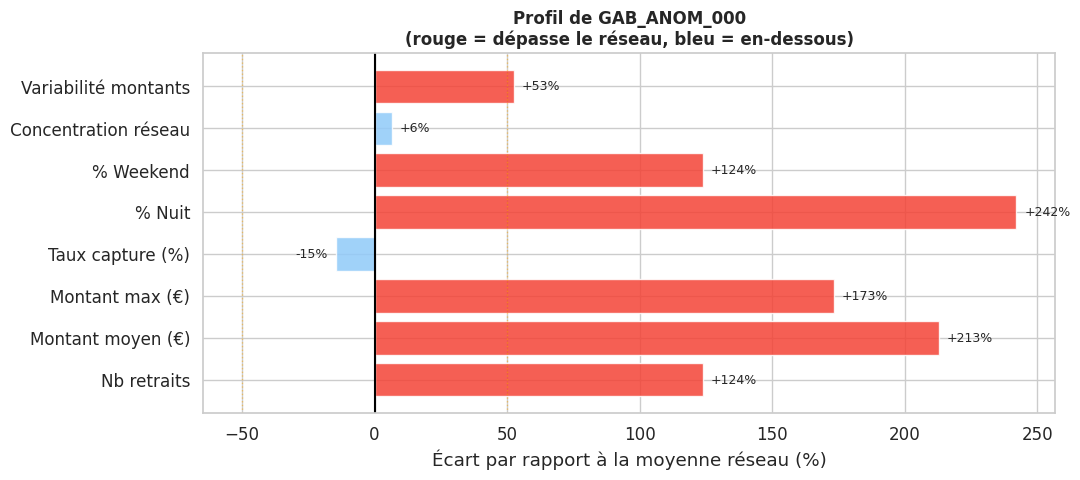

In [12]:
# ── 7.3 Bar chart des écarts pour un GAB atypique ────────────────────────────
def plot_profil_gab(gab_id, df):
    row = df[df['num_automate'] == gab_id].iloc[0]
    moy = df[df['est_anomalie']==0].mean(numeric_only=True)

    cols_affich = {
        'ret_nb'              : 'Nb retraits',
        'ret_montant_moyen'   : 'Montant moyen (€)',
        'ret_montant_max'     : 'Montant max (€)',
        'taux_capture_pct'    : 'Taux capture (%)',
        'ret_pct_nuit'        : '% Nuit',
        'ret_pct_weekend'     : '% Weekend',
        'concentration_reseau': 'Concentration réseau',
        'cv_montant'          : 'Variabilité montants',
    }

    ecarts, labels, couleurs = [], [], []
    for col, label in cols_affich.items():
        if col in row.index and col in moy.index and moy[col] != 0:
            e = (row[col] - moy[col]) / moy[col] * 100
            ecarts.append(e)
            labels.append(label)
            couleurs.append('#F44336' if e > 20 else '#2196F3' if e < -20 else '#90CAF9')

    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.barh(labels, ecarts, color=couleurs, edgecolor='white', alpha=0.85)
    ax.axvline(0,   color='black', lw=1.5)
    ax.axvline(50,  color='orange', lw=1, ls=':', alpha=0.5, label='+50%')
    ax.axvline(-50, color='orange', lw=1, ls=':', alpha=0.5)
    ax.set_xlabel('Écart par rapport à la moyenne réseau (%)')
    ax.set_title(f'Profil de {gab_id}\n(rouge = dépasse le réseau, bleu = en-dessous)',
                 fontweight='bold', fontsize=12)

    for bar, val in zip(bars, ecarts):
        ax.text(bar.get_width() + (3 if val>=0 else -3),
                bar.get_y() + bar.get_height()/2,
                f'{val:+.0f}%', va='center',
                ha='left' if val>=0 else 'right', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'profil_{gab_id}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_profil_gab(gab_top, df)

In [13]:
# ── 7.4 Radar chart : 5 dimensions métier ────────────────────────────────────
def plot_radar_dimensions(gab_id, df):
    DIMS = {
        'Volume\nretraits' : ['ret_nb','intensite_retrait'],
        'Montants'          : ['ret_montant_moyen','ret_montant_max','cv_montant'],
        'Captures'          : ['taux_capture_pct','ratio_capture'],
        'Horaires\natypiques': ['ret_pct_nuit','ret_pct_weekend'],
        'Concentration\nréseau': ['concentration_reseau'],
    }

    row = df[df['num_automate']==gab_id].mean(numeric_only=True)
    moy = df[df['est_anomalie']==0].mean(numeric_only=True)
    p95 = df[df['est_anomalie']==0].quantile(0.95, numeric_only=True)

    def score_dim(cols, row, moy, p95):
        vals = []
        for c in cols:
            if c in row.index and c in p95.index and p95[c] != moy[c]:
                v = (row[c] - moy[c]) / (p95[c] - moy[c] + 1e-9)
                vals.append(max(0, min(2, v)))
        return np.mean(vals) if vals else 0

    categories = list(DIMS.keys())
    vals_gab  = [score_dim(cols, row, moy, p95) for cols in DIMS.values()]
    vals_norm = [1.0] * len(DIMS)  # la moyenne du réseau = 1 par construction

    fig = go.Figure()
    for vals, nom, couleur in [
        (vals_gab,  f'{gab_id}',          '#F44336'),
        (vals_norm, 'Moyenne réseau',      '#2196F3'),
    ]:
        fig.add_trace(go.Scatterpolar(
            r=vals + [vals[0]],
            theta=categories + [categories[0]],
            fill='toself', name=nom,
            line_color=couleur, fillcolor=couleur, opacity=0.3
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0,2])),
        title=f'Profil par dimension — {gab_id} vs Réseau',
        height=480
    )
    fig.show()
    print('💡 Score > 1 = au-dessus de la normale | Score proche de 2 = extrême')

plot_radar_dimensions(gab_top, df)

💡 Score > 1 = au-dessus de la normale | Score proche de 2 = extrême


🔬 Calcul des SHAP values (peut prendre 30-60s)...


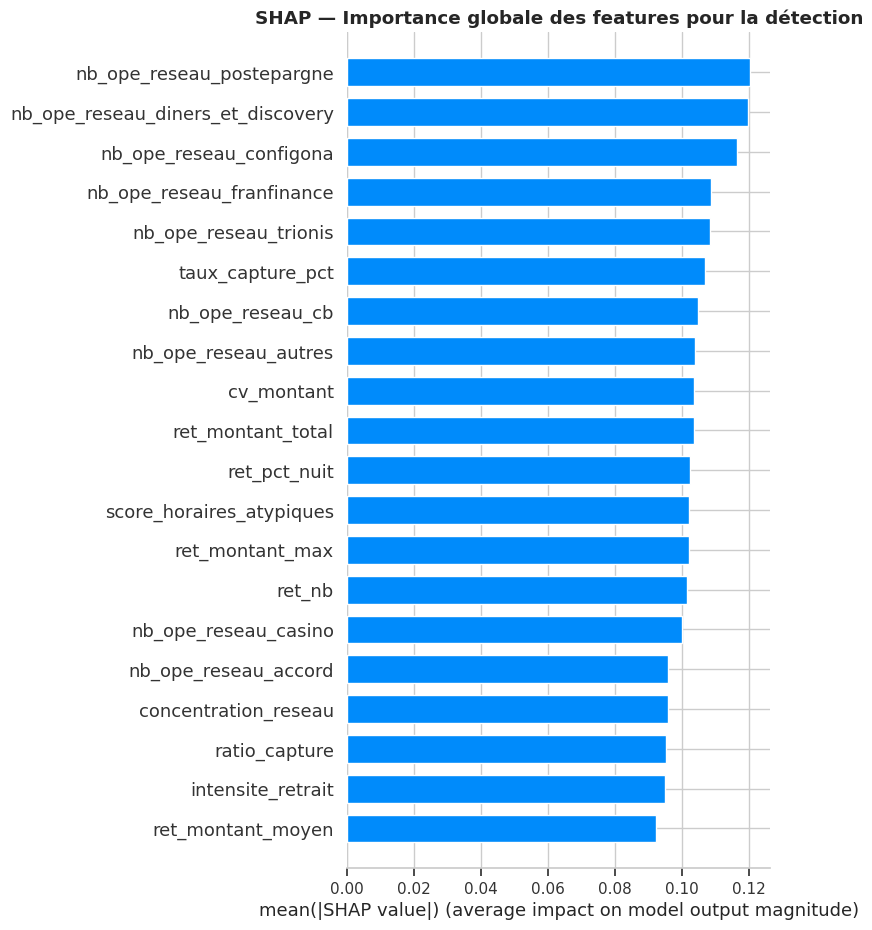

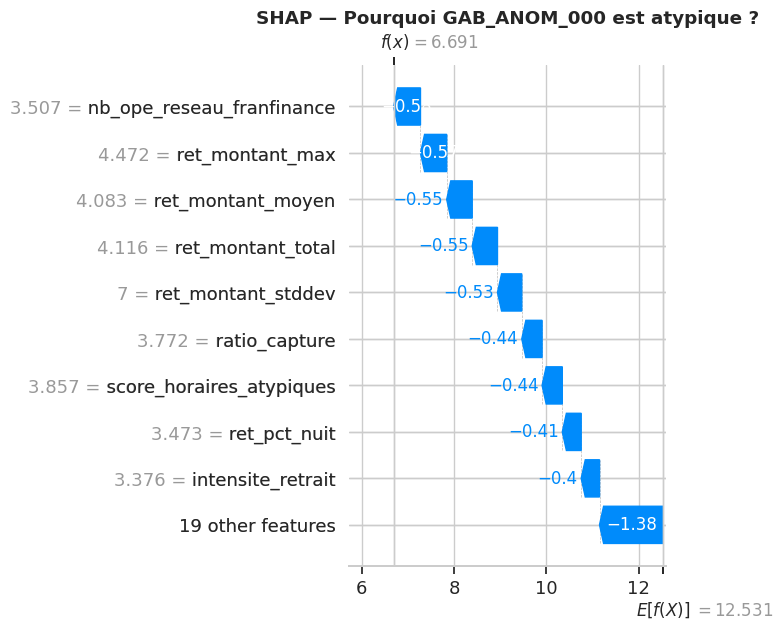

💡 Chaque barre = contribution d'une feature au score d'anomalie.
   Rouge = pousse vers "atypique" | Bleu = pousse vers "normal"


In [14]:
# ── 7.5 SHAP values — contribution mathématique de chaque feature ────────────
if SHAP_OK:
    print('🔬 Calcul des SHAP values (peut prendre 30-60s)...')
    explainer  = shap.TreeExplainer(modele)
    shap_vals  = explainer.shap_values(X_scaled)

    # Résumé global : quelles features comptent le plus ?
    plt.figure(figsize=(10,6))
    shap.summary_plot(shap_vals, X_scaled,
                      feature_names=FEATURES_MODELE,
                      plot_type='bar',
                      show=False)
    plt.title('SHAP — Importance globale des features pour la détection', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_global.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Focus sur le GAB le plus atypique
    idx_top = df[df['num_automate']==gab_top].index[0]
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals[idx_top],
            base_values=explainer.expected_value,
            data=X_scaled[idx_top],
            feature_names=FEATURES_MODELE
        ),
        show=False
    )
    plt.title(f'SHAP — Pourquoi {gab_top} est atypique ?', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_{gab_top}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💡 Chaque barre = contribution d\'une feature au score d\'anomalie.')
    print('   Rouge = pousse vers "atypique" | Bleu = pousse vers "normal"')
else:
    print('⚠️  SHAP non disponible. Installer avec : pip install shap')
    print('   Les sections 7.3 et 7.4 donnent déjà une bonne explicabilité.')

## 8. 📋 Tableau de Bord des GAB à Investiguer

In [15]:
# ── Top anomalies avec explication automatique ────────────────────────────────
top10 = df[df['est_anomalie']==1].nlargest(10,'score_risque').reset_index(drop=True)
top10.index += 1

print('🚨 TOP 10 des GAB les plus atypiques\n')
for _, row in top10.iterrows():
    expliquer_gab(row['num_automate'], df)

🚨 TOP 10 des GAB les plus atypiques


  🔴 TRÈS ATYPIQUE — GAB_ANOM_000
  Score de risque : 1.000 / 1.000
  Signaux détectés :
  🌙 Activité nocturne : 35.51 — soit 3.4× % des retraits (vs 10% en moyenne)
  📅 Activité weekend : 49.46 — soit 2.2× % des retraits (vs 22% en moyenne)
  💰 Montant moyen de retrait : 478.85 — soit 3.1× € (vs 153€ en moyenne)
  📊 Volume de retraits : 1803.84 — soit 2.2× retraits/mois (vs 805 en moyenne)

  🔴 TRÈS ATYPIQUE — GAB_ANOM_018
  Score de risque : 0.997 / 1.000
  Signaux détectés :
  ⚠️ Taux de capture de carte : 7.16 — soit 12.0× fois supérieur à la moyenne réseau
  🌙 Activité nocturne : 40.47 — soit 3.9× % des retraits (vs 10% en moyenne)
  📅 Activité weekend : 44.03 — soit 2.0× % des retraits (vs 22% en moyenne)
  💰 Montant moyen de retrait : 446.15 — soit 2.9× € (vs 153€ en moyenne)
  📊 Volume de retraits : 1657.86 — soit 2.1× retraits/mois (vs 805 en moyenne)

  🔴 TRÈS ATYPIQUE — GAB_ANOM_001
  Score de risque : 0.988 / 1.000
  Signaux détectés :
 

In [16]:
# ── Tableau exportable ────────────────────────────────────────────────────────
export = df[df['est_anomalie']==1][[
    'num_automate','score_risque',
    'ret_nb','ret_montant_moyen','taux_capture_pct',
    'ret_pct_nuit','ret_pct_weekend','type_gab_e_i','code_postal'
]].sort_values('score_risque', ascending=False).reset_index(drop=True)
export.index += 1

# export.to_csv('gab_a_investiguer.csv', index=True)  # décommenter pour exporter

display(export.style
    .background_gradient(subset=['score_risque'], cmap='Reds')
    .background_gradient(subset=['taux_capture_pct'], cmap='Oranges')
    .format({'score_risque':':.3f','ret_montant_moyen':':.0f','taux_capture_pct':':.2f',
             'ret_pct_nuit':':.1f','ret_pct_weekend':':.1f'}))

,num_automate,score_risque,ret_nb,ret_montant_moyen,taux_capture_pct,ret_pct_nuit,ret_pct_weekend,type_gab_e_i,code_postal
1,GAB_ANOM_000,:.3f,1803.840684,:.0f,:.2f,:.1f,:.1f,Interne,75001
2,GAB_ANOM_018,:.3f,1657.861602,:.0f,:.2f,:.1f,:.1f,Interne,13001
3,GAB_ANOM_001,:.3f,1496.549228,:.0f,:.2f,:.1f,:.1f,Externe,75001
4,GAB_ANOM_002,:.3f,1933.471057,:.0f,:.2f,:.1f,:.1f,Interne,69001
5,GAB_ANOM_022,:.3f,2153.585733,:.0f,:.2f,:.1f,:.1f,Externe,69001
6,GAB_ANOM_019,:.3f,1936.723662,:.0f,:.2f,:.1f,:.1f,Interne,69001
7,GAB_ANOM_025,:.3f,1647.046342,:.0f,:.2f,:.1f,:.1f,Interne,13001
8,GAB_ANOM_017,:.3f,1718.316030,:.0f,:.2f,:.1f,:.1f,Externe,69001
9,GAB_ANOM_013,:.3f,1667.702423,:.0f,:.2f,:.1f,:.1f,Externe,75001
10,GAB_ANOM_005,:.3f,1800.032101,:.0f,:.2f,:.1f,:.1f,Externe,75001


## 9. 🗺️ Carte Géographique des Anomalies

In [17]:
df_geo = df.groupby('num_automate').agg(
    longitude    =('longitude',   'first'),
    latitude     =('latitude',    'first'),
    score_risque =('score_risque','mean'),
    est_anomalie =('est_anomalie','max'),
    taux_capture =('taux_capture_pct','mean'),
    ret_nb_moyen =('ret_nb','mean'),
).reset_index()

df_geo['statut'] = df_geo['est_anomalie'].map({0:'Normal', 1:'Atypique'})

fig = px.scatter_mapbox(
    df_geo, lat='latitude', lon='longitude',
    color='statut',
    color_discrete_map={'Normal':'#2196F3','Atypique':'#F44336'},
    size='score_risque', size_max=18,
    hover_name='num_automate',
    hover_data={'taux_capture':':.2f','ret_nb_moyen':':.0f','score_risque':':.3f'},
    zoom=5, center={'lat':46.8,'lon':2.3},
    mapbox_style='carto-positron',
    title='🗺️ Réseau GAB — Normaux vs Atypiques',
    height=550
)
fig.update_layout(margin={'r':0,'t':50,'l':0,'b':0})
fig.show()

## 10. 📌 Synthèse & Recommandations

### Ce que le modèle a fait :
1. Il a observé **tous les GAB** sur leurs 30+ indicateurs simultanément  
2. Il a appris ce que ressemble un **comportement normal** du réseau  
3. Il a identifié les GAB qui **s'écartent** de ce comportement normal  
4. Il a **expliqué** en quoi chaque GAB est différent

### Ce que le modèle ne peut pas faire seul :
- ❌ Dire si c'est une fraude, une panne, ou un problème opérationnel  
- ❌ Être certain à 100% (il peut y avoir des faux positifs)  
- ✅ C'est pourquoi **la validation métier est indispensable**

### Prochaines étapes :
| Étape | Action | Responsable |
|---|---|---|
| 1 | Valider les anomalies détectées (vrai/faux positif) | Expert réseau |
| 2 | Affiner le seuil `contamination` selon retours | Data Scientist |
| 3 | Intégrer les incidents déclarés comme labels | Équipes terrain |
| 4 | Passer en production mensuelle automatique | Dataiku |
| 5 | Évoluer vers un modèle semi-supervisé | Data Science |

---
> *Le modèle est un outil d'aide à la décision. L'expertise métier reste le juge final.*